# 03 - Models and rankings under the microscope

[UFC_Pipeline](../UFC_Pipeline.ipynb) trains the models, scores them on the test period and publishes the rankings. This notebook reads what it saved in `data/processed/` and looks behind the headline numbers:

**Models**
1. Model selection on the validation period
2. Are the probabilities calibrated?
3. Confidence and accuracy
4. What the logistic regression learned
5. The model against the market

**Rankings**
6. Do the three methods agree?
7. Comparison with the official UFC rankings
8. Where the methods disagree
9. Elo through history

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from ufc_rating import plotting
from ufc_rating.config import ELO_HISTORY_CSV, MASTER_CSV, MODELS_PKL, PREDICTIONS_CSV, RANKINGS_CSV
from ufc_rating.models.training import format_scores, load_models
from ufc_rating.processing.master import read_master
from ufc_rating.ranking.elo import peak_elo
from ufc_rating.ranking.rankings import compare_with_official, latest_official_ranks, method_agreement

plotting.setup()
bundle = load_models(MODELS_PKL)
results = bundle['results']
best = results['best_stats_model']
predictions = pd.read_csv(PREDICTIONS_CSV, parse_dates=['date'])
rankings = pd.read_csv(RANKINGS_CSV)
elo_history = pd.read_csv(ELO_HISTORY_CSV, parse_dates=['date'])
master = read_master(MASTER_CSV)

## 1. Model selection on the validation period

The hyperparameters of each model were tuned by time-ordered cross-validation inside the training period. The validation period, which none of the models was fitted on, then picks the stats model used for the round-robin rankings (lowest log loss).

In [2]:
print(f'Selected for the rankings: {best}')
format_scores(results['validation'])

Selected for the rankings: LogReg


,Fights,Accuracy,AUC,Log loss,Brier
LogReg,978,60.8%,0.666,0.648,0.229
SVM,978,61.7%,0.662,0.649,0.229
RandomForest,978,59.9%,0.649,0.659,0.233
XGBoost,978,61.0%,0.651,0.657,0.232
Elo only,978,55.5%,0.571,0.686,0.246


The four models land close to each other. The linear models (logistic regression, linear SVM) are at least as good as the tree ensembles: with a few thousand fights and features that are already differences between the two fighters, there is little non-linear structure left for the trees to find.

## 2. Are the probabilities calibrated?

For a rating system the probability matters more than the pick: a "60%" should win 60% of the time. Test-period predictions are grouped by predicted probability and compared with the observed win rate.

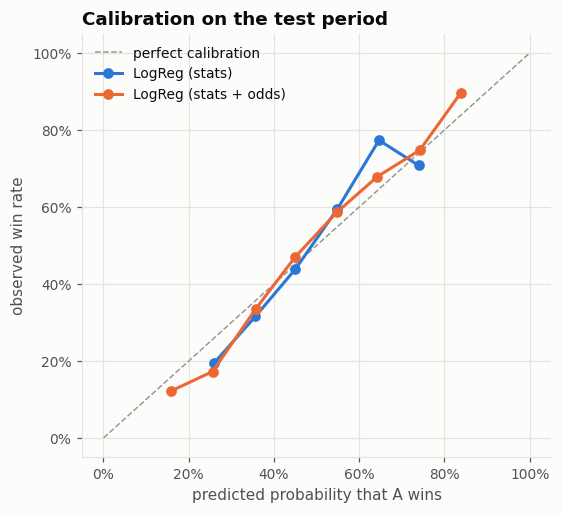

In [3]:
y = predictions['a_wins']
series = {f'{best} (stats)': predictions[f'{best} (stats)'],
          f'{best} (stats + odds)': predictions[f'{best} (stats + odds)']}

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=plotting.NEUTRAL, linewidth=1, linestyle='--', label='perfect calibration')
for (name, proba), color in zip(series.items(), plotting.SERIES):
    bins = pd.cut(proba, np.linspace(0, 1, 11))
    table = pd.DataFrame({'p': proba, 'y': y}).groupby(bins, observed=True).agg(p=('p', 'mean'), y=('y', 'mean'), n=('y', 'size'))
    table = table[table['n'] >= 20]
    ax.plot(table['p'], table['y'], marker='o', color=color, label=name)
ax.set_xlabel('predicted probability that A wins')
ax.set_ylabel('observed win rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Calibration on the test period')
ax.legend(loc='upper left')
plt.show()

Both models rank fights in the right order, but the stats-only model is **underconfident**: when it gives a fighter 55% or 65%, that fighter actually wins about 60% or 77% of the time. The strong regularisation chosen by cross-validation on the older fights pulls its probabilities towards 50%, and recent fights turn out to be more predictable than older ones. The odds give the second model the confidence to single out clear favourites, and it stays closer to the diagonal.

Underconfidence does not change which fighter is favoured, so accuracy, AUC and the round-robin order are unaffected; it does cost some log loss. Recalibrating on the validation period would be the next step.

## 3. Confidence and accuracy

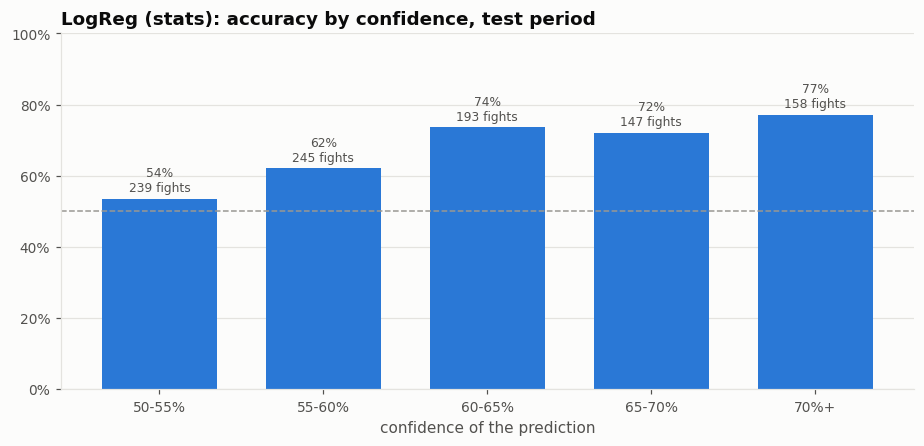

In [4]:
proba = predictions[f'{best} (stats)']
confidence = np.maximum(proba, 1 - proba)
correct = (proba > 0.5) == (y == 1)
buckets = pd.cut(confidence, [0.5, 0.55, 0.6, 0.65, 0.7, 1.0], include_lowest=True,
                 labels=['50-55%', '55-60%', '60-65%', '65-70%', '70%+'])
by_confidence = pd.DataFrame({'correct': correct, 'bucket': buckets}).groupby('bucket', observed=False)['correct'].agg(['mean', 'size'])

ax = by_confidence['mean'].plot.bar(color=plotting.BLUE, width=0.7)
ax.axhline(0.5, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title(f'{best} (stats): accuracy by confidence, test period')
ax.set_xlabel('confidence of the prediction')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='x', visible=False)
for x, (acc, n) in enumerate(by_confidence.itertuples(index=False)):
    ax.text(x, acc + 0.02, f'{acc:.0%}\n{n} fights', ha='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

Accuracy rises with confidence, as it should. A large share of fights sits in the 50-60% band where the model honestly does not know: UFC matchmaking pairs fighters of similar level on purpose.

## 4. What the logistic regression learned

The features are scaled to unit variance, so each coefficient is the change in log-odds of winning for a one-standard-deviation advantage over the opponent.

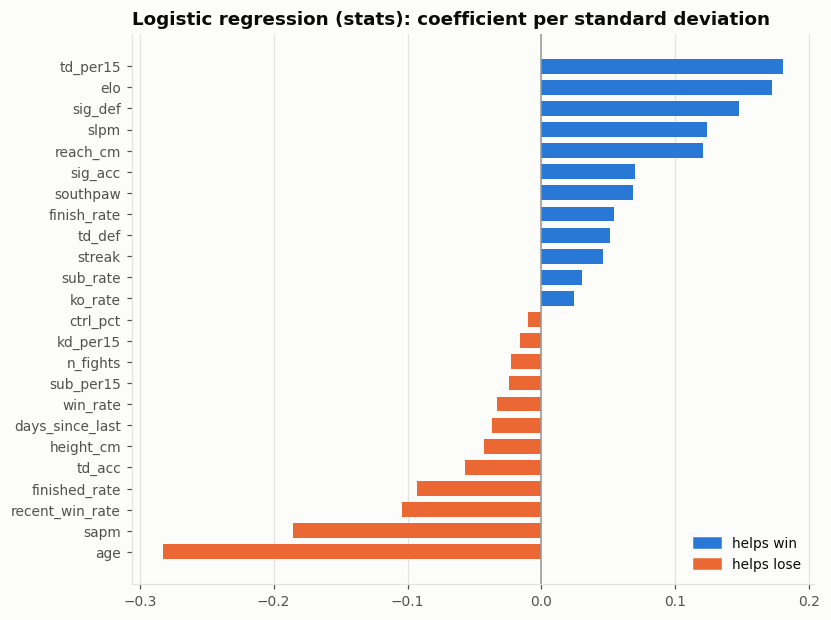

In [5]:
logreg = bundle['stats']['LogReg'].named_steps['model']
coefs = pd.Series(logreg.coef_[0], index=[f.removeprefix('delta_') for f in bundle['stats_features']]).sort_values()

colors = [plotting.BLUE if c > 0 else plotting.ORANGE for c in coefs]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(coefs.index, coefs.values, color=colors, height=0.7)
ax.axvline(0, color=plotting.NEUTRAL, linewidth=1)
ax.set_title('Logistic regression (stats): coefficient per standard deviation')
ax.grid(axis='y', visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (plotting.BLUE, plotting.ORANGE)]
ax.legend(handles, ['helps win', 'helps lose'], loc='lower right')
plt.show()

- The largest weights go to **age** (the younger fighter), **strikes absorbed** (fewer is better), **takedown volume**, **Elo**, striking defence and output, and **reach**: the same signals as in the single-feature analysis of [02_feature_engineering](02_feature_engineering.ipynb).
- The raw win rate and recent form get *negative* weights. This does not mean that winning is bad: Elo and the streak already summarise the record, and among strongly correlated features the regression only keeps a small correction on the extra ones. Coefficients of correlated features have to be read together.
- The strong L2 regularisation chosen by cross-validation keeps every coefficient small. Since the model has no intercept and only differences as inputs, it has no notion of corner or card position.

## 5. The model against the market

On the test fights with odds: how often does the stats model pick the same winner as the bookmakers, and when they disagree, who is right?

In [6]:
market = predictions.dropna(subset=['a_odds_prob'])
model_pick = market[f'{best} (stats)'] > 0.5
market_pick = market['a_odds_prob'] > 0.5
a_won = market['a_wins'] == 1
agree = model_pick == market_pick

summary = pd.DataFrame({
    'fights': [agree.sum(), (~agree).sum()],
    'model right': [(model_pick == a_won)[agree].mean(), (model_pick == a_won)[~agree].mean()],
    'market right': [(market_pick == a_won)[agree].mean(), (market_pick == a_won)[~agree].mean()],
}, index=['model and market agree', 'they disagree'])
summary[['model right', 'market right']] = summary[['model right', 'market right']].map('{:.1%}'.format)
summary

,fights,model right,market right
model and market agree,547,73.9%,73.9%
they disagree,151,43.7%,56.3%


The two agree on most fights. When they disagree, the market is right more often than the model: its extra information (injuries, short-notice replacements, weight cuts, stylistic match-ups) is exactly what public fight statistics cannot see.

## 6. Do the three methods agree?

Spearman correlation between the ranks given by each pair of methods, per division (1 = identical order).

In [7]:
method_agreement(rankings)

,fighters,Elo vs Weighted,Elo vs Model,Weighted vs Model
division,,,,
Flyweight,35,0.80,0.86,0.73
Bantamweight,53,0.73,0.71,0.74
Featherweight,56,0.69,0.67,0.70
Lightweight,77,0.80,0.72,0.77
Welterweight,65,0.73,0.77,0.80
Middleweight,56,0.67,0.82,0.77
Light Heavyweight,34,0.64,0.50,0.71
Heavyweight,33,0.83,0.77,0.90
Women's Strawweight,37,0.77,0.80,0.85


The three methods agree broadly (correlations mostly between 0.6 and 0.9) while measuring different things: Elo rewards results against rated opponents, the weighted score rewards a style, the model rewards the profile that wins fights.

## 7. Comparison with the official UFC rankings

The odds dataset records each fighter's official rank at fight time (until spring 2026). Each fighter's most recent official rank is compared with the rank each method gives them, over the fighters present in both lists.

In [8]:
official = latest_official_ranks(master)
print(f"Official ranks observed between {official['rank_date'].min().date()} and {official['rank_date'].max().date()}")
compare_with_official(rankings, official)

Official ranks observed between 2025-03-22 and 2026-03-21


,ranked fighters compared,Elo,Weighted,Model
division,,,,
Flyweight,15,0.61,0.56,0.47
Bantamweight,15,0.83,0.53,0.51
Featherweight,12,0.89,0.43,0.65
Lightweight,14,0.53,0.21,-0.00
Welterweight,13,0.63,0.04,0.30
Middleweight,13,0.83,0.56,0.80
Light Heavyweight,15,0.61,0.19,0.35
Heavyweight,14,0.67,0.51,0.56
Women's Strawweight,17,0.51,0.37,0.13


Elo is the closest to the official rankings in every division. That is expected: the official panel ranks fighters by *who they beat*, and Elo is the only method that knows the opponents. The weighted and model rankings judge how a fighter fights, regardless of opposition, so they rate highly some prospects the UFC has not tested against ranked opposition yet.

## 8. Where the methods disagree

Among each division's current top 10 by consensus, the fighters whose three ranks are furthest apart.

In [9]:
top = rankings[rankings['rank'] <= 10].copy()
rank_cols = ['Elo rank', 'Weighted rank', 'Model rank']
top['spread'] = top[rank_cols].max(axis=1) - top[rank_cols].min(axis=1)
(top.sort_values('spread', ascending=False)
    .head(10)[['division', 'Fighter', 'UFC record', 'Elo', 'Weighted', 'Model'] + rank_cols]
    .reset_index(drop=True))

,division,Fighter,UFC record,Elo,Weighted,Model,Elo rank,Weighted rank,Model rank
0,Lightweight,Dustin Poirier,22-9,1648,0.734,0.569,3,7,25
1,Featherweight,Arnold Allen,12-3,1621,0.552,0.653,4,24,8
2,Welterweight,Ian Machado Garry,10-2,1627,0.530,0.699,5,25,6
3,Bantamweight,Payton Talbott,5-1,1564,0.824,0.662,20,1,7
4,Welterweight,Max Holloway,24-9,1688,0.616,0.636,2,18,11
5,Bantamweight,Raul Rosas Jr.,6-1,1572,0.686,0.777,17,9,1
6,Light Heavyweight,Jimmy Crute,6-4-2,1532,0.707,0.552,20,4,10
7,Light Heavyweight,Robert Whittaker,18-7,1641,0.485,0.611,2,18,6
8,Light Heavyweight,Jiri Prochazka,6-3,1566,0.768,0.507,9,2,17
9,Middleweight,Bo Nickal,6-1,1572,0.783,0.745,17,3,2


Two typical cases:

- **Proven veterans**: a long record against strong opponents gives a high Elo, while an older profile, recent losses or a grinding style pull down the statistical methods.
- **Unbeaten prospects**: excellent statistics and a perfect record push the weighted and model ranks up, but with few fights against rated opponents the Elo is still close to its starting value.

## 9. Elo through history

In [10]:
peak_elo(elo_history, top=15)

,Fighter,Peak Elo,Reached on
1,Jon Jones,1775,2024-11-16
2,Islam Makhachev,1752,2026-08-15
3,Georges St-Pierre,1747,2017-11-04
4,Kamaru Usman,1723,2021-11-06
5,Anderson Silva,1716,2012-10-13
6,Tony Ferguson,1698,2019-06-08
7,Max Holloway,1697,2024-04-13
8,Donald Cerrone,1696,2016-12-10
9,Charles Oliveira,1696,2022-05-07
10,Leon Edwards,1695,2023-12-16


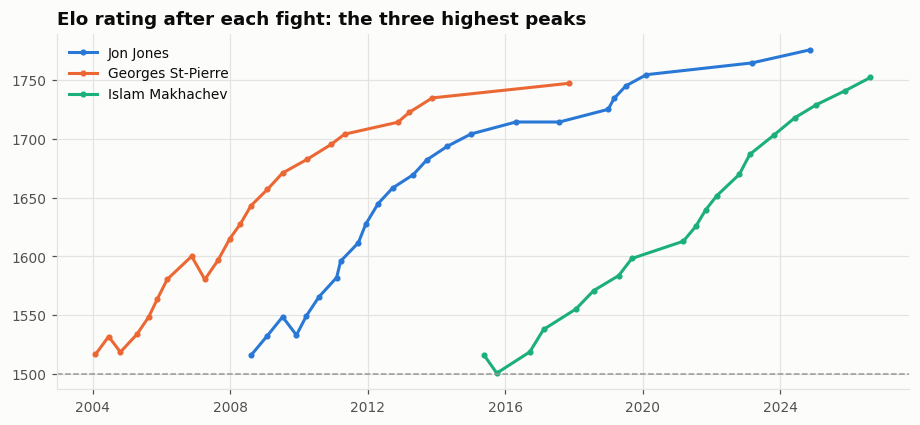

In [11]:
legends = ['Jon Jones', 'Georges St-Pierre', 'Islam Makhachev']
fig, ax = plt.subplots()
for name, color in zip(legends, plotting.SERIES):
    career = elo_history[elo_history['fighter_name'] == name].sort_values('date')
    ax.plot(career['date'], career['elo_after'], marker='o', markersize=3, color=color, label=name)
ax.axhline(1500, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.set_title('Elo rating after each fight: the three highest peaks')
ax.set_xlabel('')
ax.legend(loc='upper left')
plt.show()

Elo climbs with every win and drops after a loss, more sharply when the loss is an upset (Jones's 2009 disqualification, St-Pierre's 2007 knockout by Matt Serra, Makhachev's 2015 knockout). The highest peaks come from long winning runs against rated opposition, so the length of a career matters: Khabib Nurmagomedov, unbeaten in 13 UFC fights, peaks lower (12th) than fighters who won for longer.